In [1]:
import json
import os
import logging
import numpy as np
import requests
from PIL import Image
import scipy.stats
import matplotlib.pyplot as plt
import sys
import plotly.express as px

# pandas
import pandas as pd
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)
# check环境
print(sys.executable)
print(sys.version)

/nfs_beijing/kubeflow-user/yujie/.conda/envs/icey/bin/python
3.8.18 (default, Sep 11 2023, 13:40:15) 
[GCC 11.2.0]


In [2]:
data = pd.read_csv('all_single_mut.csv', index_col=0)
stability_pred = pd.read_csv('all_single_mut_stability_input.pred.csv').set_index('unique_id')['pred'].to_dict()
data['stability_ddg'] = data['unique_id'].apply(lambda x: stability_pred[x])
data['mut_posis'] = data['pdb_mutation'].apply(lambda x: x.split(','))
data['posi'] = data['pdb_mutation'].apply(lambda x: int(x[2:-1]))
data['mt'] = data['pdb_mutation'].apply(lambda x: x[-1])
data['wt'] = data['pdb_mutation'].apply(lambda x: x[0])

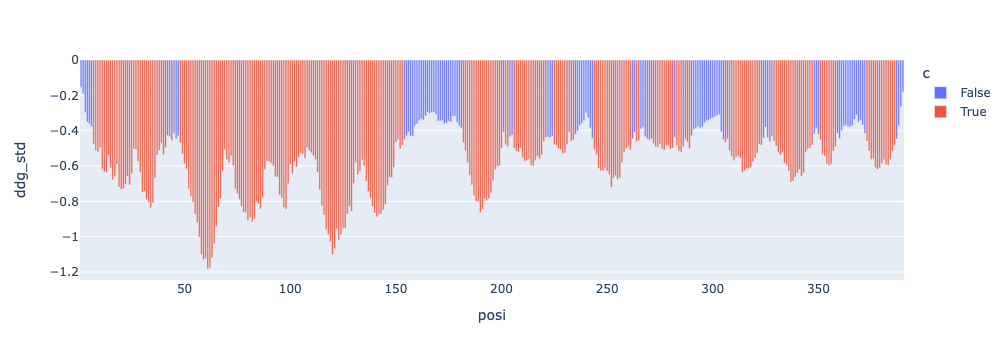

In [5]:
_data = data.groupby(['posi']).apply(
    lambda x: (x['stability_ddg'].mean() - x['stability_ddg'].std()) 
).rename('ddg_std').reset_index()

def sliding_window_average(data, window_size):
    if window_size <= 0:
        raise ValueError("Window size must be positive")
    if len(data) < window_size:
        raise ValueError("Data length must be greater than or equal to window size")

    window = np.ones(window_size) / window_size
    result = np.convolve(data, window, mode='same')
    
    return result
    
_data['ddg_std'] = sliding_window_average(_data['ddg_std'], 7)

_data['c'] = _data['ddg_std'] < -0.45
px.bar(_data,
      x='posi', y='ddg_std', color='c'
      )